# Проект: классификация

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from  sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing  import LabelEncoder
from sklearn import linear_model 
from sklearn import tree 
from sklearn import ensemble 
from sklearn import metrics 
from sklearn import preprocessing 
from sklearn.model_selection import train_test_split 
from sklearn.feature_selection import SelectKBest, f_classif
import warnings
warnings.filterwarnings('ignore')

## Часть 1. Знакомство с данными, обработка пропусков и выбросов

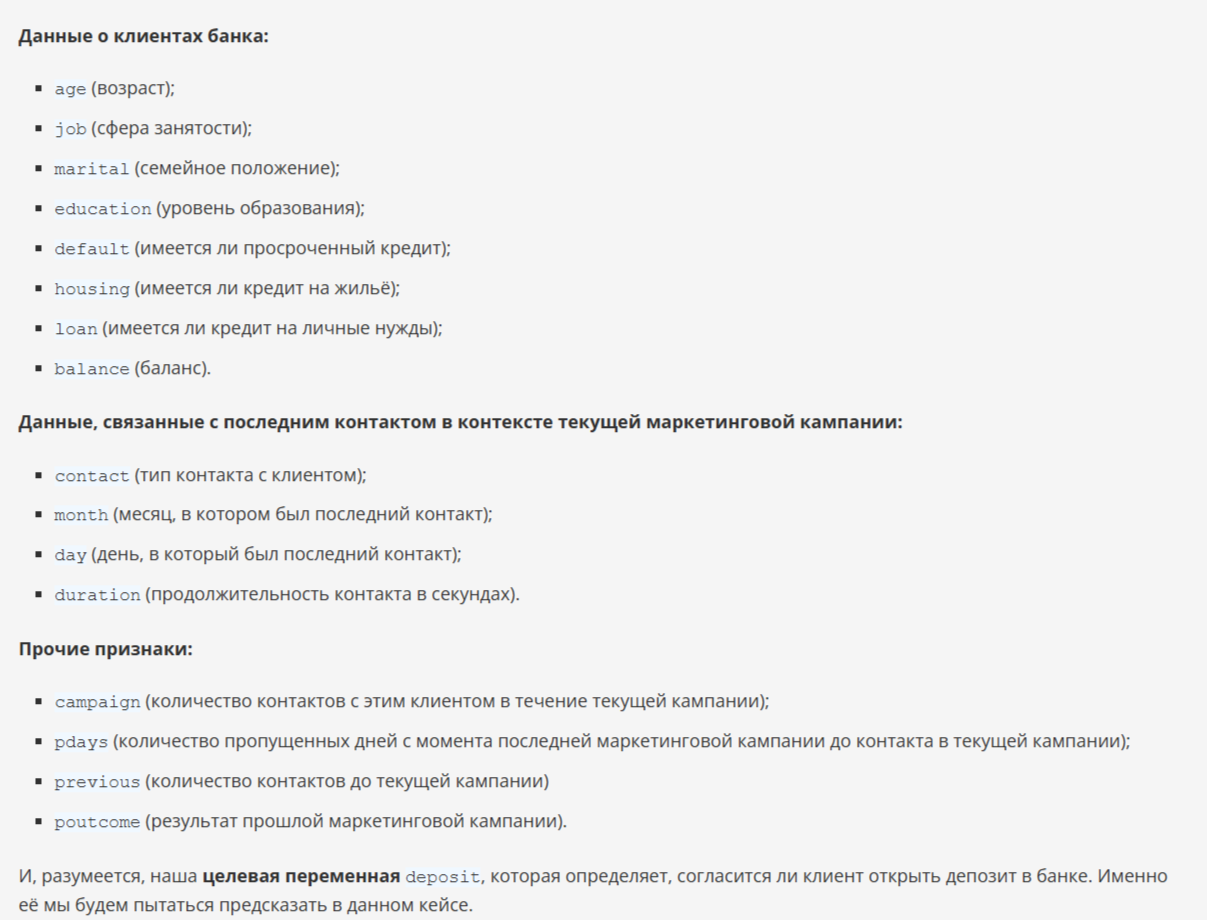

### Задание 1. 
**Первичный анализ данных**

In [78]:
df = pd.read_csv(r'C:\Users\user\Desktop\Skilfactory\data1\bank_fin.csv', sep = ';')

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11137 non-null  object
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(6), object(11)
memory usage: 1.4+ MB


### Задание 2
**Есть в столбце job зашифрованные пропуски?**

In [80]:
df['job'].value_counts()

job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64

Да, элемент unknown является скрытым пропуском.

### Задание 3
**Преобразуйте признак balance таким образом, чтобы он корректно считывался, как вещественное число (float)**

In [81]:
df['balance'] = df['balance'].apply(lambda x: float(str(x).replace(',', '.').replace('$', '').replace(' ', '')))
print(f'Среднее значение: {np.round(np.mean(df['balance']), 3)}')

Среднее значение: 1529.129


### Задание 4
**Обработайте пропуски в признаки balance , заменив их на медианные значения по данному признаку**

In [82]:
df['balance'] = df['balance'].fillna(np.median(df['balance'].dropna()))
print(f"Среднее значение: {np.round(np.mean(df['balance']), 3)}")

Среднее значение: 1526.936


### Задание 5
**Обработайте пропуски в категориальных признаках: job и education, заменив их на модальные значения**

In [83]:
mode_job = df['job'].mode()[0]
mode_education = df['education'].mode()[0]
df['job'] = df['job'].apply(lambda x:  mode_job if x=='unknown' else x)
df['education'] = df['education'].apply(lambda x:  mode_education if x=='unknown' else x)

In [84]:
mean_balance = df[(df['job'] == 'management') & (df['education'] == 'secondary')]['balance'].mean()
print(f'Среднее значение баланса по самой популярной работе и самому популярному образованию: {np.round(mean_balance, 3)}')

Среднее значение баланса по самой популярной работе и самому популярному образованию: 1598.883


### Задание 6
**Удалите все выбросы для признака balance**

In [85]:
quantile_1 = np.quantile(df['balance'], q=0.25)
quantile_3 = np.quantile(df['balance'], q=0.75)
IQR = quantile_3 - quantile_1
upper_ = df[df['balance'] > quantile_3 + 1.5*IQR]
lower_ = df[df['balance'] < quantile_1 - 1.5*IQR]
upper = quantile_3 + 1.5*IQR
lower = quantile_1 - 1.5*IQR
print(f'Нижняя граница: {quantile_1 - 1.5*IQR}')
print(f'Верхняя граница: {quantile_3 + 1.5*IQR}')
print(f'Количество наблюдений ниже границы: {lower_.shape}')
print(f'Количество наблюдений выше границы: {upper_.shape}')

df = df[(df['balance'] >= lower) & (df['balance'] <= upper)]
print(f'Количество данных без выбросов: {df.shape[0]}')

Нижняя граница: -2241.0
Верхняя граница: 4063.0
Количество наблюдений ниже границы: (4, 17)
Количество наблюдений выше границы: (1053, 17)
Количество данных без выбросов: 10105


## Часть 2:  Разведывательный анализ

### Задание 1
**Изучите соотношение классов в ваших данных на предмет несбалансированности**

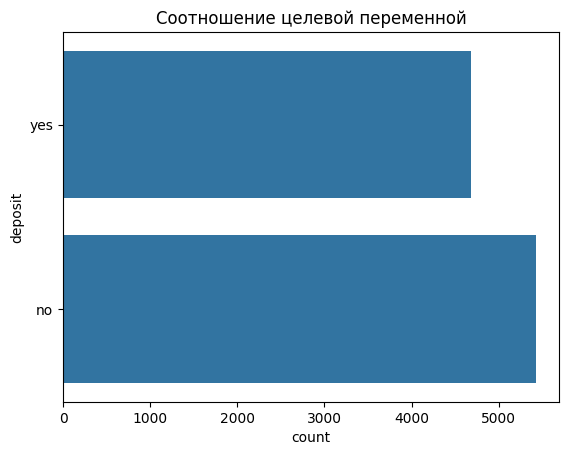

In [86]:
sns.countplot(df['deposit'])
plt.title('Соотношение целевой переменной');

In [87]:
df['deposit'].value_counts()

deposit
no     5424
yes    4681
Name: count, dtype: int64

### Задания 2 и 3
**Рассчитайте описательные статистики для количественных переменных**

In [88]:
import plotly.express as px
fig = px.histogram(df,
             x='age',
             title='Распределение возраста клиентов')

fig.update_layout(
    xaxis_title='Возраст',
    yaxis_title='Частота'
)
fig.show()
fig.write_html(r"C:\Users\user\Desktop\Skilfactory\Проекты\Полный цикл разработки модели\plotly\plots1.html")

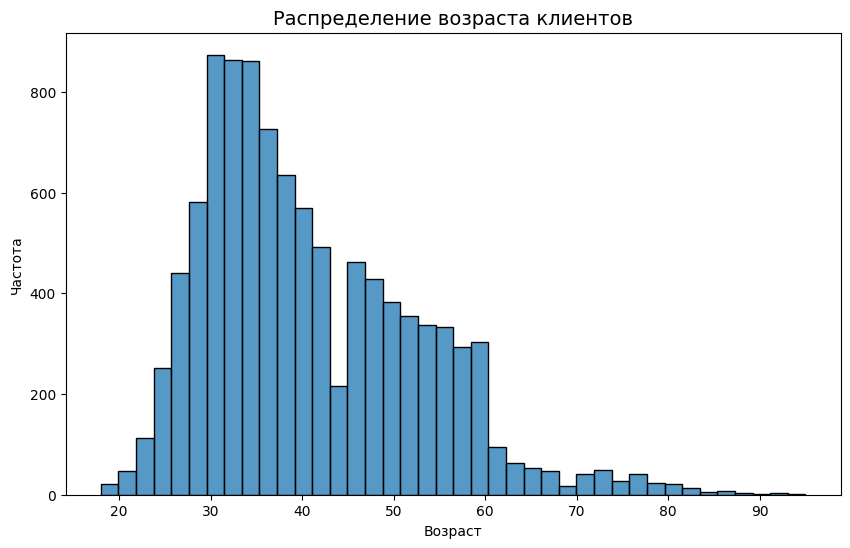

In [89]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', bins=40)
plt.title('Распределение возраста клиентов', fontsize=14)
plt.xlabel('Возраст')
plt.ylabel('Частота')
plt.show()

In [90]:
fig = px.histogram(df, 
                   x='duration',
                   title='Распределение времени разговора')

fig.update_layout(
    xaxis_title='Длительность разговора',
    yaxis_title='Частота'
)
fig.show()
fig.write_html(r"C:\Users\user\Desktop\Skilfactory\Проекты\Полный цикл разработки модели\plotly\plots2.html")

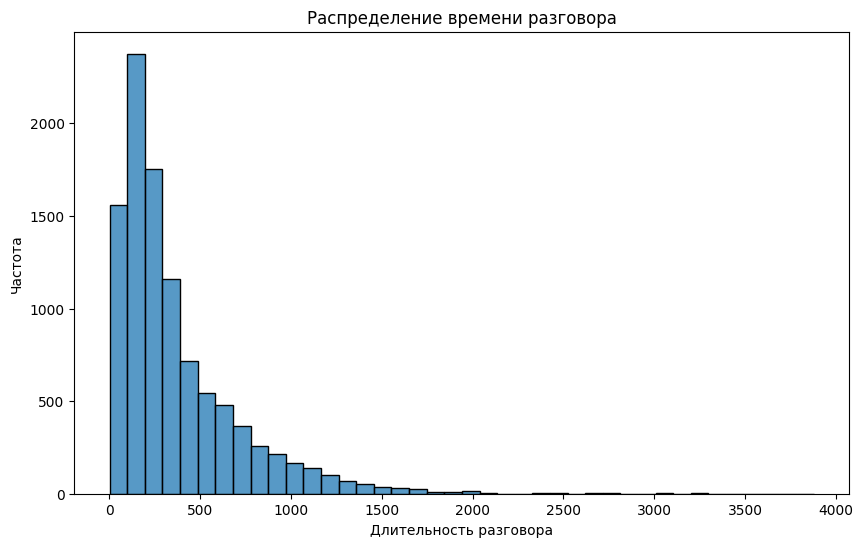

In [91]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='duration', bins=40)
plt.title('Распределение времени разговора')
plt.xlabel('Длительность разговора')
plt.ylabel('Частота')
plt.show()

In [92]:
df[['age', 'duration']].describe()

,age,duration
count,10105.000000,10105.000000
mean,40.895497,368.742603
std,11.734931,346.651524
min,18.000000,2.000000
25%,32.000000,137.000000
50%,38.000000,252.000000
75%,48.000000,490.000000
max,95.000000,3881.000000


### Задания 4 и 5
**Рассчитайте описательные статистики для категориальных переменных**

In [93]:
table1 = pd.DataFrame(df['month'].value_counts().rename('month_count')).reset_index()
table2 = pd.DataFrame(df['job'].value_counts().rename('job_count')).reset_index()
df_tables = pd.concat([table1, table2], axis=1)
display(df_tables)

,month,month_count,job,job_count
0,may,2617,management,2315.0
1,jul,1418,blue-collar,1807.0
2,aug,1385,technician,1638.0
3,jun,1104,admin.,1246.0
4,apr,830,services,868.0
5,nov,780,retired,663.0
6,feb,709,self-employed,358.0
7,oct,335,unemployed,332.0
8,jan,319,student,326.0
9,sep,278,entrepreneur,300.0


**Постройте визуализации, иллюстрирующие результаты**

In [94]:
fig = px.pie(df,
             'job', title='Распределение сферы занятости')
fig.show()
fig.write_html(r"C:\Users\user\Desktop\Skilfactory\Проекты\Полный цикл разработки модели\plotly\plots3.html")

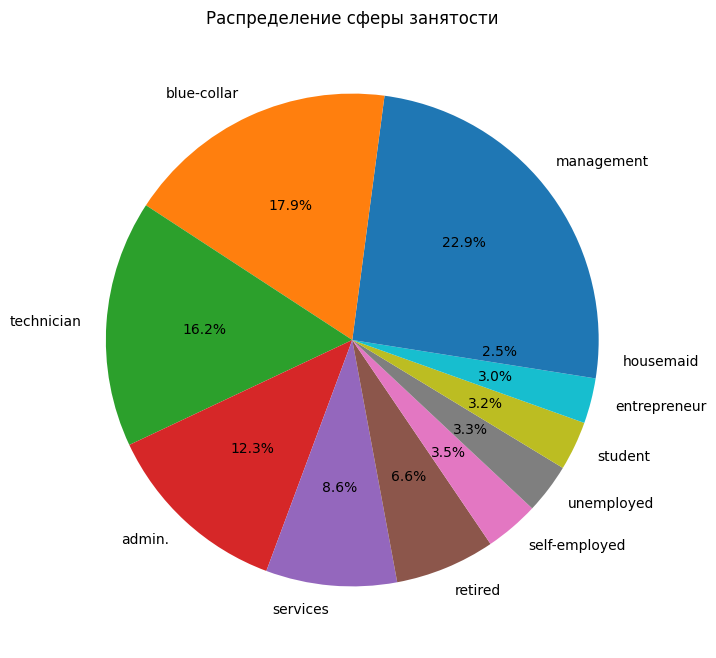

In [95]:
job_counts = df['job'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(job_counts.values, labels=job_counts.index, autopct='%1.1f%%')
plt.title('Распределение сферы занятости')
plt.show()

In [96]:
fig1 = px.pie(df,
              'month',
              title='Распределение маркетинговой компании про месяцам')
fig1.show()
fig.write_html(r"C:\Users\user\Desktop\Skilfactory\Проекты\Полный цикл разработки модели\plotly\plots4.html")

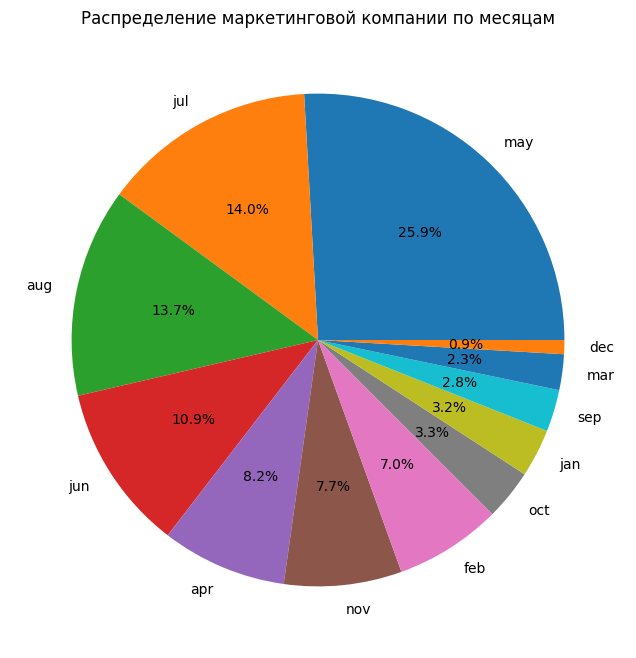

In [97]:
month_counts = df['month'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(month_counts.values, labels=month_counts.index, autopct='%1.1f%%')
plt.title('Распределение маркетинговой компании по месяцам')
plt.show()

### Задание 6
**Узнайте, для какого статуса предыдущей маркетинговой кампании успех в текущей превалирует над количеством неудач.**

In [98]:
df.groupby('poutcome')['deposit'].value_counts()

poutcome  deposit
failure   no          562
          yes         547
other     yes         265
          no          216
success   yes         861
          no           84
unknown   no         4562
          yes        3008
Name: count, dtype: int64

### Задание 7
**Узнайте, в каком месяце чаще всего отказывались от предложения открыть депозит**

In [99]:
df.groupby('month')['deposit'].value_counts(normalize=True)*100

month  deposit
apr    yes        61.807229
       no         38.192771
aug    no         55.956679
       yes        44.043321
dec    yes        90.322581
       no          9.677419
feb    yes        54.442877
       no         45.557123
jan    no         60.815047
       yes        39.184953
jul    no         58.956276
       yes        41.043724
jun    no         54.891304
       yes        45.108696
mar    yes        89.873418
       no         10.126582
may    no         67.863966
       yes        32.136034
nov    no         58.461538
       yes        41.538462
oct    yes        81.492537
       no         18.507463
sep    yes        83.453237
       no         16.546763
Name: proportion, dtype: float64

### Задание 8
**Создайте возрастные группы и определите, в каких группах более склонны открывать депозит, чем отказываться от предложения**

In [100]:
def age_func(x):
    if x < 30:
        return 1
    elif 30 <= x < 40:
        return 2
    elif 40 <= x < 50:
        return 3
    elif 50 <= x < 60:
        return 4
    else:
        return 5
df['age_group'] = df['age'].apply(age_func)


In [101]:
pivot_table = pd.pivot_table(data=df, 
                             columns='deposit',
                             values='balance',
                             index='age_group',
                             aggfunc='count')
pivot_table

deposit,no,yes
age_group,,
1,594,861
2,2245,1716
3,1444,938
4,984,670
5,157,496


<Figure size 1200x600 with 0 Axes>

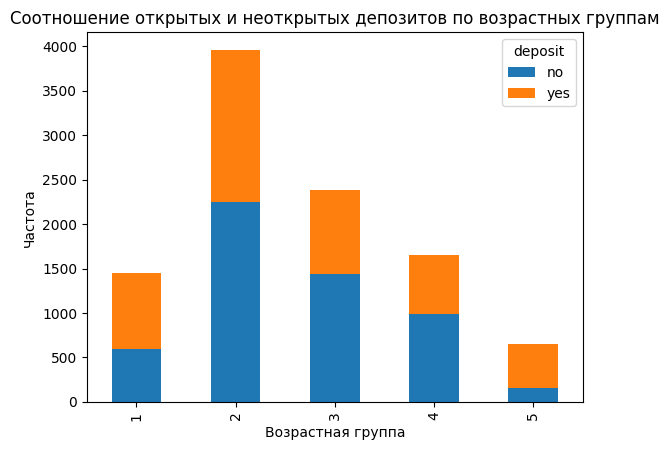

In [102]:
plt.figure(figsize=(12, 6));
pivot_table.plot(kind='bar', stacked=True)
plt.title('Соотношение открытых и неоткрытых депозитов по возрастных группам')
plt.xlabel('Возрастная группа')
plt.ylabel('Частота')
plt.show();

### Задания 9 и 10
**Постройте визуализации для открывших и неоткрывших депозит в зависимости от семейного статуса**

<Figure size 1200x600 with 0 Axes>

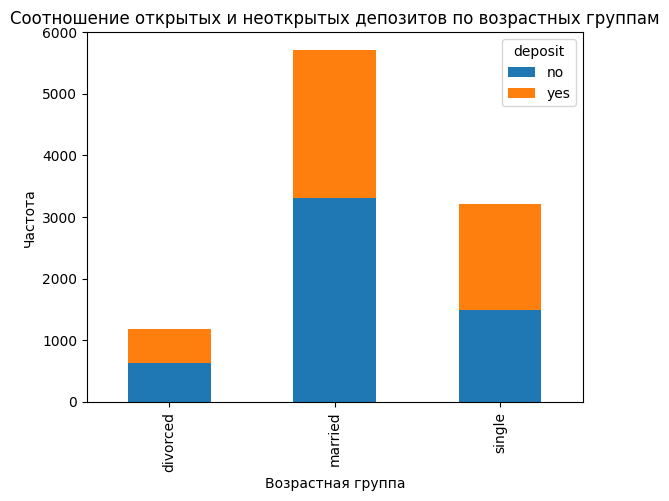

In [103]:
pivot_table1 = pd.pivot_table(data=df, 
                             columns='deposit',
                             values='balance',
                             index='marital',
                             aggfunc='count')
plt.figure(figsize=(12, 6));
pivot_table1.plot(kind='bar', stacked=True)
plt.title('Соотношение открытых и неоткрытых депозитов по возрастных группам')
plt.xlabel('Возрастная группа')
plt.ylabel('Частота')
plt.show();

**Постройте визуализации для открывших и неоткрывших депозит в зависимости от образования**

<Figure size 1200x600 with 0 Axes>

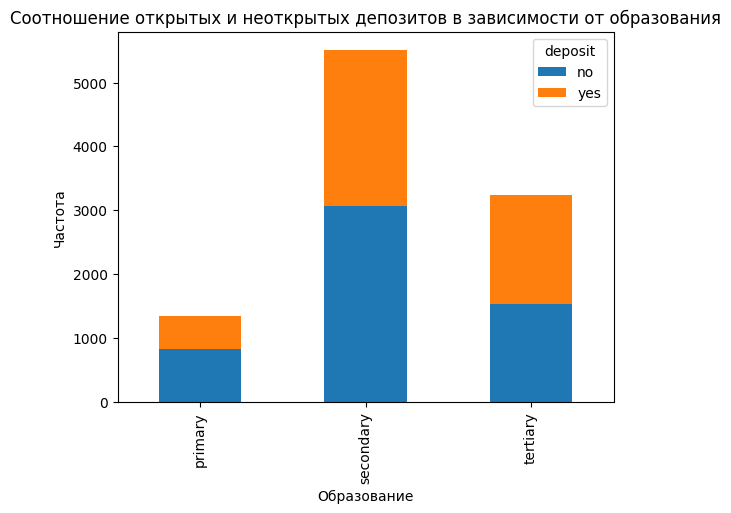

In [104]:
pivot_table2 = pd.pivot_table(data=df, 
                             columns='deposit',
                             values='balance',
                             index='education',
                             aggfunc='count')
plt.figure(figsize=(12, 6));
pivot_table2.plot(kind='bar', stacked=True)
plt.title('Соотношение открытых и неоткрытых депозитов в зависимости от образования')
plt.xlabel('Образование')
plt.ylabel('Частота')
plt.show();

**Постройте визуализации для открывших и неоткрывших депозит в зависимости от вида профессиональной занятости**

<Figure size 1200x600 with 0 Axes>

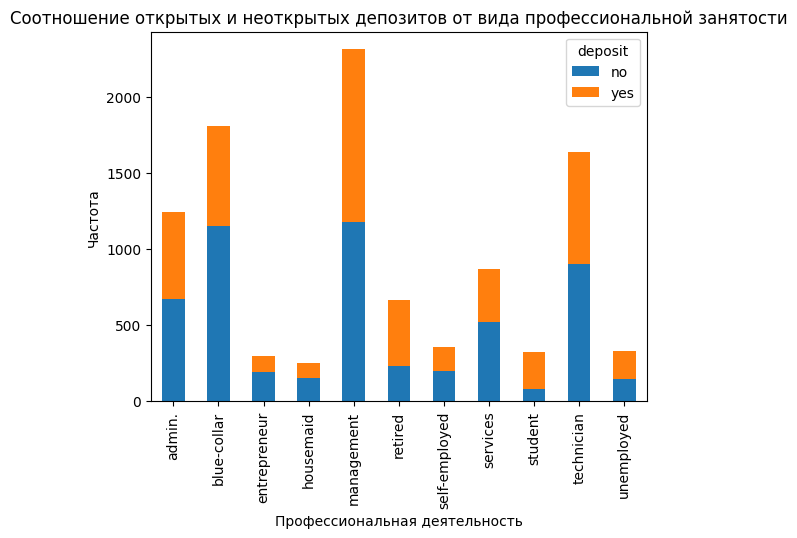

In [105]:
pivot_table3 = pd.pivot_table(data=df, 
                             columns='deposit',
                             values='balance',
                             index='job',
                             aggfunc='count')
plt.figure(figsize=(12, 6));
pivot_table3.plot(kind='bar', stacked=True)
plt.title('Соотношение открытых и неоткрытых депозитов от вида профессиональной занятости')
plt.xlabel('Профессиональная деятельность')
plt.ylabel('Частота')
plt.show();

### Задание 11
**Постройте сводную таблицу, чтобы определить люди с каким образованием и семейным статусом наиболее многочисленны
(если рассматривать тех, кто открыл депозит)**

In [106]:
# постройте сводную таблицу, чтобы определить люди с каким образованием и семейным статусом наиболее многочисленны
#(если рассматривать тех, кто открыл депозит)
df['deposit_yes'] = df['deposit'].apply(lambda x: 1 if x=='yes' else 0)
df['deposit_no'] = df['deposit'].apply(lambda x: 1 if x=='no' else 0)
pivot_table_all = pd.pivot_table(data=df,
                                 values='balance',
                                 aggfunc='count',
                                 index=['education', 'marital'],
                                 columns='deposit')
pivot_table_all

deposit               no   yes
education marital             
primary   divorced    91    96
          married    641   339
          single     100    82
secondary divorced   370   283
          married   1830  1289
          single     866   879
tertiary  divorced   163   174
          married    832   784
          single     531   755

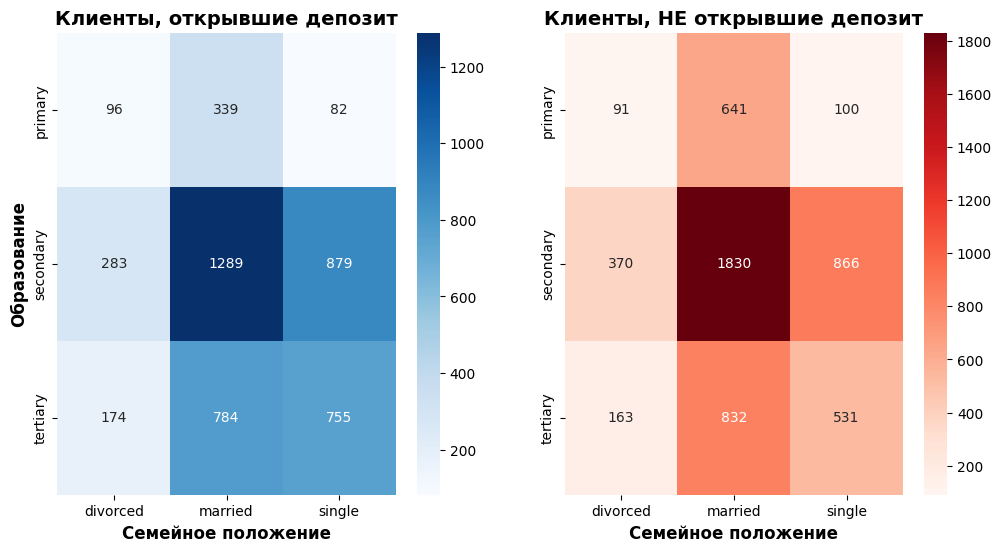

In [107]:
pivot_table_yes = pd.pivot_table(data=df,
                                 values='deposit_yes',
                                 aggfunc='sum',
                                 index='education',
                                 columns='marital')
pivot_table_no = pd.pivot_table(data=df,
                                 values='deposit_no',
                                 aggfunc='sum',
                                 index='education',
                                 columns='marital')

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
sns.heatmap(pivot_table_yes, annot=True, fmt=".0f", ax=ax1, cmap='Blues')
ax1.set_title('Клиенты, открывшие депозит', fontsize=14, fontweight='bold')
ax1.set_xlabel('Семейное положение', fontsize=12, fontweight='bold')
ax1.set_ylabel('Образование', fontsize=12, fontweight='bold')

sns.heatmap(pivot_table_no, annot=True, fmt=".0f", ax=ax2, cmap='Reds')
ax2.set_title('Клиенты, НЕ открывшие депозит', fontsize=14, fontweight='bold')
ax2.set_xlabel('Семейное положение', fontsize=12, fontweight='bold');
ax2.set_ylabel('');
df.drop(['deposit_yes', 'deposit_no'], axis=1, inplace=True)

## Часть 3: преобразование данных

### Задание 1
**Преобразуйте уровни образования**

In [108]:
l_encoder = LabelEncoder()
df['education'] = l_encoder.fit_transform(df['education'])
df['education'].sum()

11995

### Задания 2 и 3
**Преобразуйте бинарные переменные в представление из нулей и единиц**

In [109]:
df['deposit'] = df['deposit'].apply(lambda x: 1 if x=='yes' else 0)
df['default'] = df['default'].apply(lambda x: 1 if x=='yes' else 0)
df['housing'] = df['housing'].apply(lambda x: 1 if x=='yes' else 0)
df['loan'] = df['loan'].apply(lambda x: 1 if x=='yes' else 0)
print(np.round(df['deposit'].std(), 3))

0.499


In [110]:
print(np.round(df['default'].mean() + df['housing'].mean() + df['loan'].mean(), 3))

0.635


### Задание 4
**Создайте дамми-переменные**

In [111]:
df= pd.get_dummies(df, columns=['job', 'marital', 'contact', 'month', 'poutcome']).astype('int')


### Задания 5 и 6
**Постройте корреляционную матрицу и оцените данные на предмет наличия мультиколлинеарности**

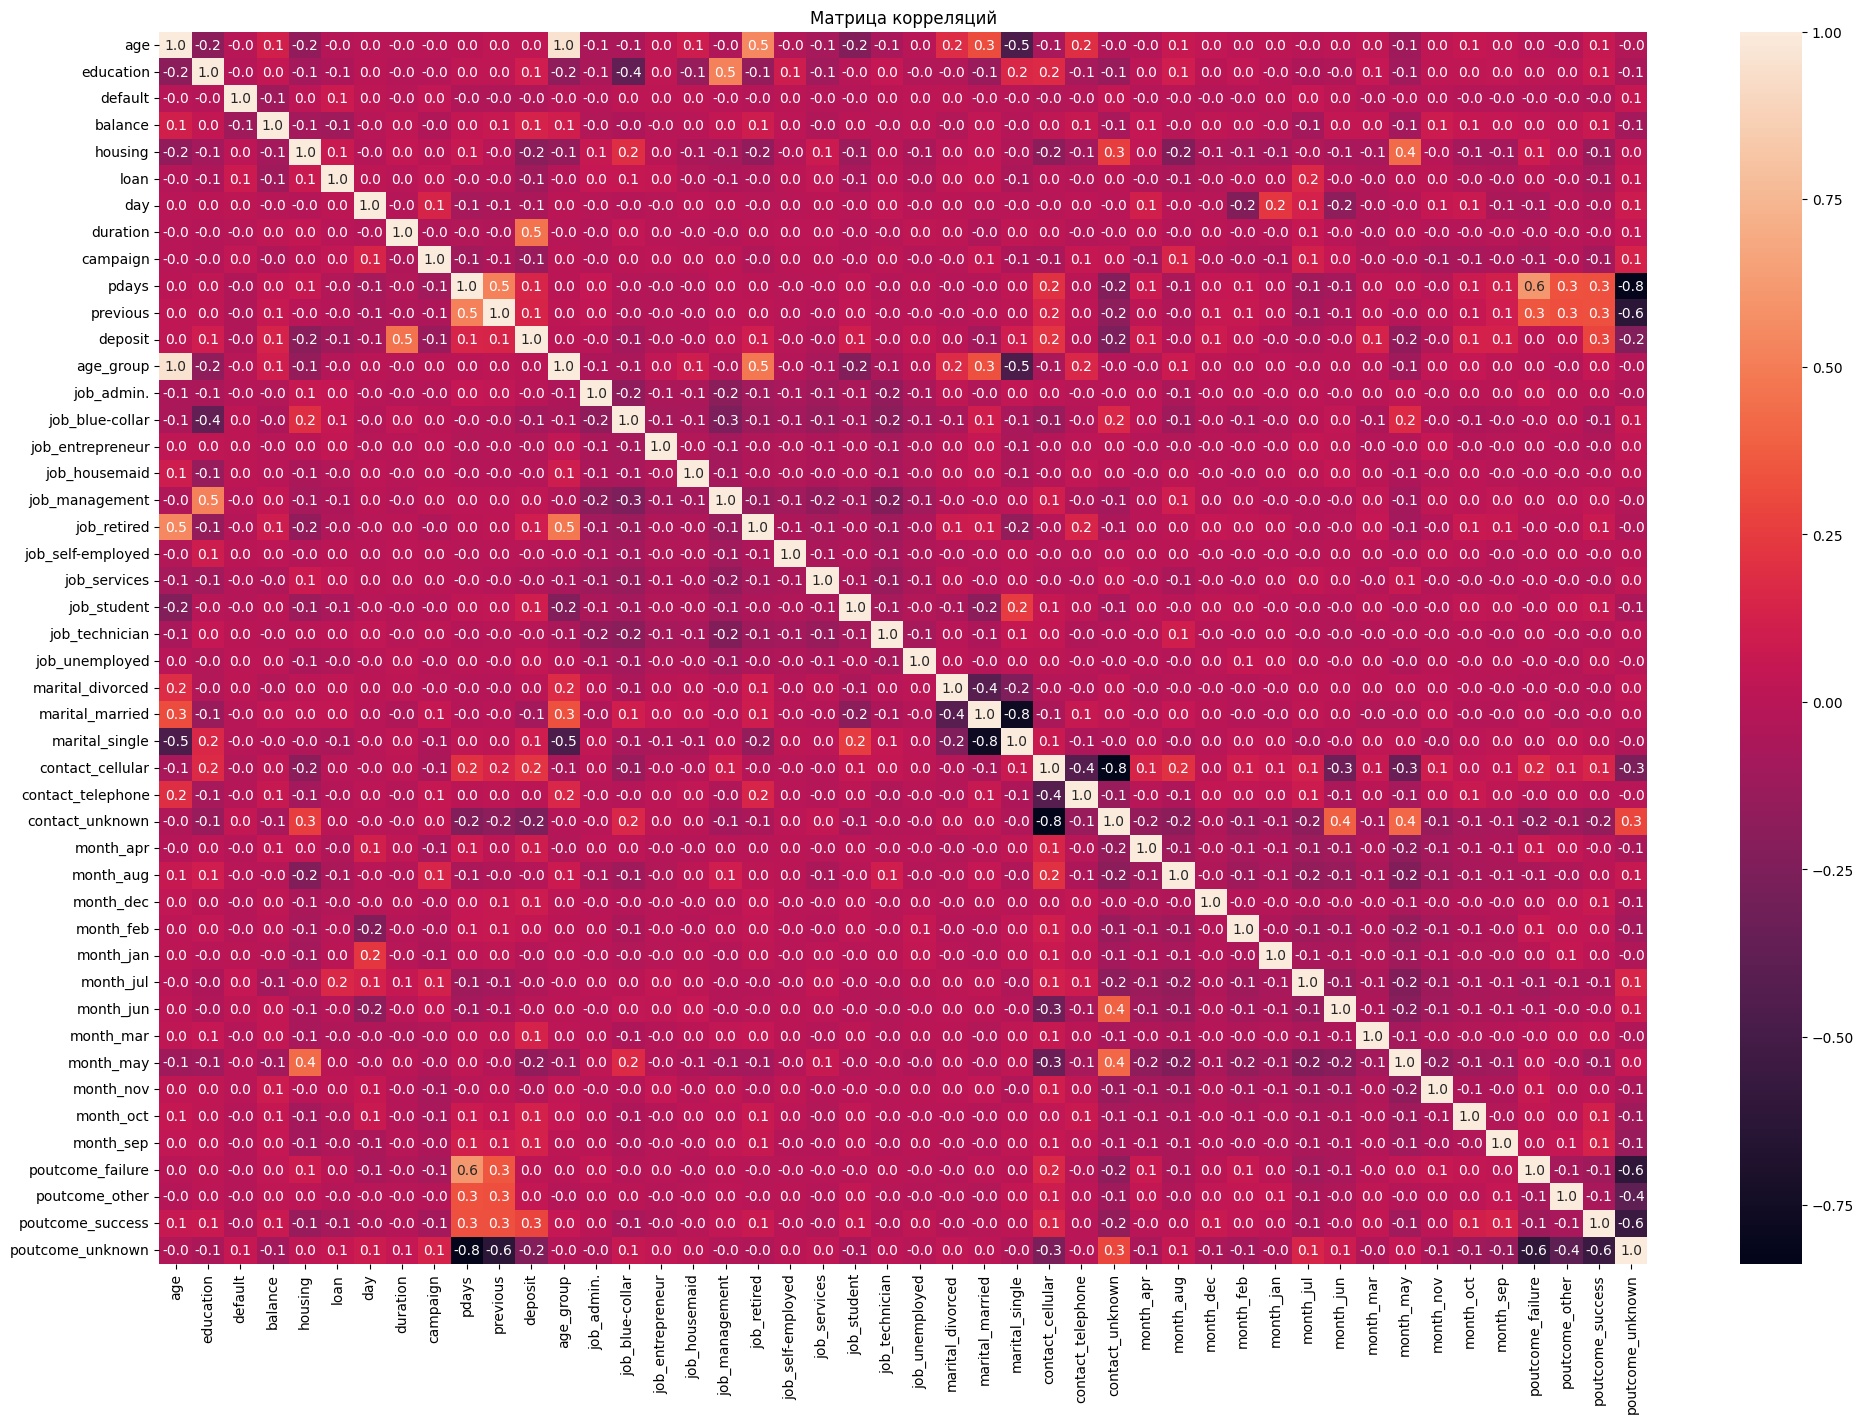

In [112]:
plt.figure(figsize=(24, 16))
plt.title('Матрица корреляций')
sns.heatmap(df.corr(), annot=True, fmt='.1f');

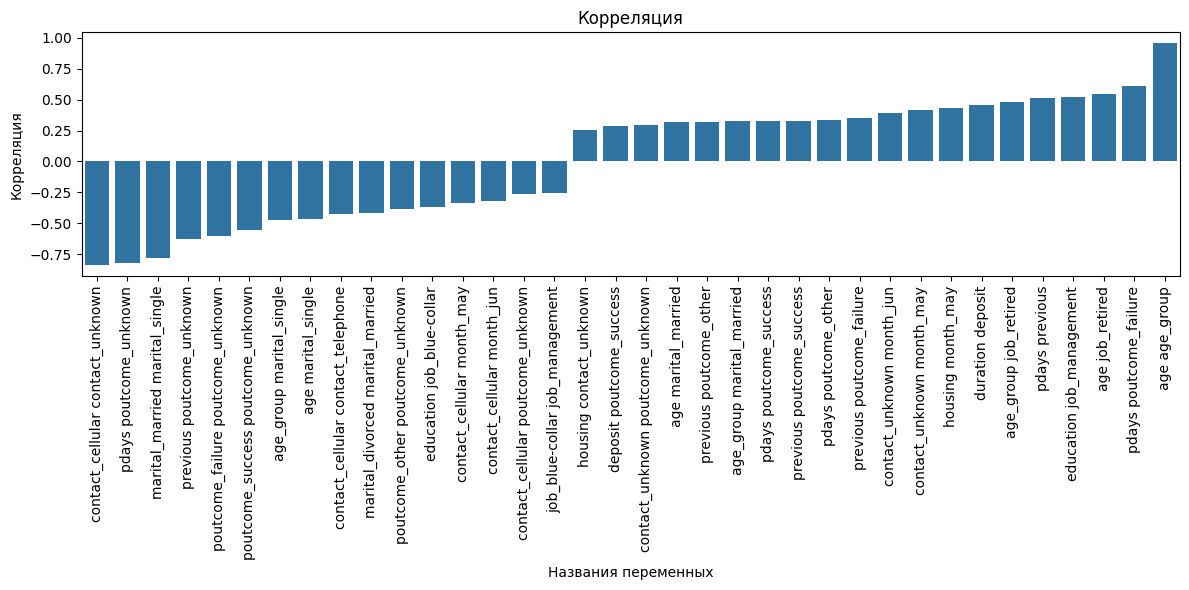

In [113]:
df_corr = df.corr()
df_corr_new = df_corr.stack().reset_index()
df_corr_new = df_corr_new[df_corr_new['level_0'] != df_corr_new['level_1']]
df_corr_new.drop_duplicates(subset=[0], inplace=True)
df_corr_new_filtr = df_corr_new[abs(df_corr_new[0]) > 0.25]
df_corr_new_filtr['name'] = df_corr_new_filtr['level_0']+' '+df_corr_new_filtr['level_1']
df_corr_new_filtr.drop(['level_0', 'level_1'], axis=1, inplace=True)
df_corr_new_filtr.sort_values(by=0, inplace=True)

# График
plt.figure(figsize=(12, 6))
sns.barplot(data=df_corr_new_filtr, x='name', y=0)
plt.xticks(rotation=90)
plt.title('Корреляция')
plt.xlabel('Названия переменных')
plt.ylabel('Корреляция')
plt.tight_layout() 
plt.show()

### Задания 7 и 8
**Разделите признаки на обучающую и тестовую выборки**

In [114]:
X = pd.DataFrame(df.drop(['deposit'], axis=1))
y = df[['deposit']]
 
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state = 42, test_size = 0.33)

In [115]:
X_test.shape
y_test.mean()

deposit    0.463268
dtype: float64

### Задание 9
**С помощью SelectKBest отберите 15 наиболее подходящих признаков**

In [116]:
selector = SelectKBest(score_func=f_classif, k=15)
X_selected = selector.fit_transform(X, y)
Selected_mask = selector.get_support()
selected_features = X.columns[Selected_mask]
selected_features
print(selected_features)
# Отбираем признаки 
X_train_sel, X_test_sel = X_train[selected_features], X_test[selected_features]

Index(['balance', 'housing', 'loan', 'duration', 'campaign', 'pdays',
       'previous', 'contact_cellular', 'contact_unknown', 'month_mar',
       'month_may', 'month_oct', 'month_sep', 'poutcome_success',
       'poutcome_unknown'],
      dtype='object')


### Задание 10
**Нормализуйте данные с помощью minmaxsxaler**

In [117]:
from sklearn.preprocessing import MinMaxScaler
minmax_scaler = MinMaxScaler()
minmax_scaler.fit(X_train_sel)
X_train = minmax_scaler.fit_transform(X_train_sel)
X_test = minmax_scaler.transform(X_test_sel)

In [118]:
X_test.mean(axis=0)[0]

0.46823674223097866

# Часть 4: Решение задачи классификации: логистическая регрессия и решающие деревья

### Задание 1
**Обучите логистическую регрессию и рассчитайте метрики качества**

In [119]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(solver='sag',random_state=42, max_iter=1000)
logreg.fit(X_train, y_train)
y_test_pred = logreg.predict(X_test)
print(metrics.classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.79      0.87      0.83      1790
           1       0.83      0.73      0.78      1545

    accuracy                           0.80      3335
   macro avg       0.81      0.80      0.80      3335
weighted avg       0.81      0.80      0.80      3335



### Задания 2,3,4
**Обучите решающие деревья, настройте максимальную глубину**

In [120]:
from sklearn.tree import DecisionTreeClassifier
tree_1 = DecisionTreeClassifier(random_state=42, criterion='entropy')
tree_1.fit(X_train, y_train)
y_train_pred_tree = tree_1.predict(X_train)
y_test_pred_tree = tree_1.predict(X_test)
print(metrics.classification_report(y_train, y_train_pred_tree))
print(metrics.classification_report(y_test, y_test_pred_tree))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3634
           1       1.00      1.00      1.00      3136

    accuracy                           1.00      6770
   macro avg       1.00      1.00      1.00      6770
weighted avg       1.00      1.00      1.00      6770

              precision    recall  f1-score   support

           0       0.77      0.76      0.77      1790
           1       0.73      0.74      0.74      1545

    accuracy                           0.75      3335
   macro avg       0.75      0.75      0.75      3335
weighted avg       0.75      0.75      0.75      3335



### Задание 5
**Подберите гиперпараметры**

In [121]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
kf = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
params_grid = {'max_depth' : list(range(1, 30))}
GridSearch = GridSearchCV(
    estimator=tree_1,
    param_grid=params_grid,
    cv=kf,
    n_jobs=-1,
    scoring='accuracy',
    return_train_score=True
)

GridSearch.fit(X_train, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'max_depth': [1, 2, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,criterion,'entropy'


In [122]:
results_G_S_1 = pd.DataFrame(GridSearch.cv_results_)
best_index = GridSearch.best_index_
accuracy_test_G_S_1 = np.round(results_G_S_1.loc[best_index, 'mean_test_score'], 3)
print(f'Среднее F1-score на валидационных фолдах лучшей модели: {accuracy_test_G_S_1}')
print(f'Наилучшие значения гиперпараметров: {GridSearch.best_params_}')
print(f'Значение F1-score на тестовой выборке: {np.round(GridSearch.score(X_test, y_test), 3)}')

Среднее F1-score на валидационных фолдах лучшей модели: 0.806
Наилучшие значения гиперпараметров: {'max_depth': 9}
Значение F1-score на тестовой выборке: 0.798


In [123]:
px.line(results_G_S_1, x='param_max_depth', y=['mean_test_score', 'mean_train_score'])


In [124]:
grid_params = {'min_samples_split': [2, 5, 7, 10],
'max_depth':[3,5,7]}
GridSearch = GridSearchCV(
    estimator=tree_1,
    param_grid=grid_params,
    cv=kf,
    n_jobs=-1,
    scoring='f1',
    return_train_score=True
)

GridSearch.fit(X_train, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'max_depth': [3, 5, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,criterion,'entropy'


In [125]:
results_G_S_2 = pd.DataFrame(GridSearch.cv_results_)
best_index = GridSearch.best_index_
accuracy_test_G_S_2 = np.round(results_G_S_1.loc[best_index, 'mean_test_score'], 3)
print(f'Среднее F1-score на валидационных фолдах лучшей модели: {accuracy_test_G_S_1}')
print(f'Наилучшие значения гиперпараметров: {GridSearch.best_params_}')
print(f'Значение F1-score на тестовой выборке: {np.round(GridSearch.score(X_test, y_test), 3)}')

Среднее F1-score на валидационных фолдах лучшей модели: 0.806
Наилучшие значения гиперпараметров: {'max_depth': 7, 'min_samples_split': 10}
Значение F1-score на тестовой выборке: 0.784


# Часть 5: Решение задачи классификации: ансамбли моделей и построение прогноза

### Задание 1
**Обучите на ваших данных случайный лес**

In [126]:
from sklearn.ensemble import RandomForestClassifier
RandomForest = ensemble.RandomForestClassifier(n_estimators = 100, criterion = 'gini', min_samples_leaf = 5, max_depth = 10, random_state = 42)
RandomForest.fit(X_train, y_train)
y_test_pred = RandomForest.predict(X_test)
print(metrics.classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.85      0.82      0.84      1790
           1       0.80      0.83      0.82      1545

    accuracy                           0.83      3335
   macro avg       0.83      0.83      0.83      3335
weighted avg       0.83      0.83      0.83      3335



### Задания 2 и 3
**Используйте для классификации градиентный бустинг и сравните качество со случайным лесом**

In [127]:
from sklearn.ensemble import GradientBoostingClassifier
Grad_Boosting = ensemble.GradientBoostingClassifier(learning_rate = 0.05, n_estimators = 300, min_samples_leaf = 5, max_depth = 5, random_state = 42)
Grad_Boosting.fit(X_train, y_train)
y_pred_test = Grad_Boosting.predict(X_test)
print(metrics.classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.85      0.82      0.83      1790
           1       0.80      0.83      0.81      1545

    accuracy                           0.82      3335
   macro avg       0.82      0.82      0.82      3335
weighted avg       0.83      0.82      0.82      3335



### Задание 4
**объедините уже известные вам алгоритмы с помощью стекинга **

In [128]:
from sklearn.ensemble import StackingClassifier
estimators = [
    ('lr', logreg),
    ('dt',  DecisionTreeClassifier(max_depth=7, min_samples_split=10, random_state=42)),
     ('grad_boost', Grad_Boosting)
]

# Создаем объект класса стекинг
reg = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(random_state=42))

# Обучаем модель
reg.fit(X_train, y_train)

,estimators,"[('lr', ...), ('dt', ...), ...]"
,final_estimator,LogisticRegre...ndom_state=42)
,cv,None
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [129]:
y_pred = reg.predict(X_test)
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.84      0.84      1790
           1       0.81      0.81      0.81      1545

    accuracy                           0.82      3335
   macro avg       0.82      0.82      0.82      3335
weighted avg       0.82      0.82      0.82      3335



### Задание 5
**Оцените, какие признаки демонстрируют наибольшую  важность в модели градиентного бустинга**

In [130]:
feature_names = [f'feature_{i}' for i in selected_features]
importance = pd.Series(Grad_Boosting.feature_importances_, index=feature_names)
print(importance.nlargest(10))

feature_duration            0.514145
feature_poutcome_success    0.118988
feature_contact_unknown     0.078994
feature_balance             0.061918
feature_pdays               0.055452
feature_housing             0.050464
feature_month_mar           0.027025
feature_month_oct           0.019516
feature_campaign            0.018008
feature_month_sep           0.015613
dtype: float64


### Задания 6,7,8
**Подберите гиперпараметры**

In [131]:
import optuna
from sklearn.model_selection import cross_val_score

In [132]:
def optuna_rf(trial):
    n_estimators = trial.suggest_int('n_estimators', 100, 200, 300)
    max_depth = trial.suggest_int('max_depth', 10, 30, 1);
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 10, 1)
    
    RandomForest = RandomForestClassifier(random_state=42, n_estimators=n_estimators, max_depth=max_depth, min_samples_leaf=min_samples_leaf)
    
    scores = cross_val_score(RandomForest, X=X_train, y=y_train, cv=kf, scoring='f1', n_jobs=-1)
    score = np.mean(scores)
    return score

In [133]:
study = optuna.create_study(study_name='RandomForest', direction='maximize')
study.optimize(optuna_rf, n_trials=30)

[I 2025-11-16 22:00:38,156] A new study created in memory with name: RandomForest
[I 2025-11-16 22:00:38,739] Trial 0 finished with value: 0.8144251196887577 and parameters: {'n_estimators': 100, 'max_depth': 20, 'min_samples_leaf': 8}. Best is trial 0 with value: 0.8144251196887577.
[I 2025-11-16 22:00:39,291] Trial 1 finished with value: 0.8157899579962591 and parameters: {'n_estimators': 100, 'max_depth': 11, 'min_samples_leaf': 9}. Best is trial 1 with value: 0.8157899579962591.
[I 2025-11-16 22:00:39,981] Trial 2 finished with value: 0.8180896265527571 and parameters: {'n_estimators': 100, 'max_depth': 29, 'min_samples_leaf': 3}. Best is trial 2 with value: 0.8180896265527571.
[I 2025-11-16 22:00:40,582] Trial 3 finished with value: 0.8143180575924477 and parameters: {'n_estimators': 100, 'max_depth': 27, 'min_samples_leaf': 9}. Best is trial 2 with value: 0.8180896265527571.
[I 2025-11-16 22:00:41,192] Trial 4 finished with value: 0.8144625877445725 and parameters: {'n_estimators

In [134]:
print(study.best_params)
print(study.best_value)
params = study.best_params

{'n_estimators': 100, 'max_depth': 11, 'min_samples_leaf': 4}
0.8202215971562026


In [135]:
RandomForest = ensemble.RandomForestClassifier(**params, random_state = 42)
RandomForest.fit(X_train, y_train)
y_test_pred = RandomForest.predict(X_test)
print(metrics.classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1790
           1       0.80      0.84      0.82      1545

    accuracy                           0.83      3335
   macro avg       0.83      0.83      0.83      3335
weighted avg       0.83      0.83      0.83      3335

